# Sticky-HMM model comparison

`state_hmm.ipynb` found that the **IO-HMM**'s inferred states don't behave as hoped:
alternation-path "purity" (fraction of a direct within-patch path sharing one dominant
state) is only ~0.5 at K=3/4/5 (~0% fully single-state), and change-of-mind capture is
inconsistent across K. Diagnosis: IOHMM's transition model has **no persistence prior**
— nothing biases it toward self-transitions, so states track fast-changing turn geometry
rather than a slower behavioral mode.

This notebook compares that reference against **sticky** alternatives (a Dirichlet
self-transition prior, `kappa=100` pseudo-counts on the diagonal — the same mechanism
`ssm`'s own `StickyTransitions` uses) — this was the one alternative angle scoped in for
this round (segment/trip-level modeling, a supervised-ceiling diagnostic, and
change-point detection were considered and explicitly left out).

**Families compared, K = 3/4/5, same session (`10_09_2025`), same held-out split:**
1. **IO-HMM** (reference, unchanged, `alpha=1.0`) — covariates → state → `turn_type`.
2. **Sticky-Categorical** (`hmmlearn.CategoricalHMM`) — `turn_type` sequence *alone*,
   sticky prior. The "based on turn directions" angle.
3. **Sticky-Gaussian** (`hmmlearn.GaussianHMM`) — behavioral covariates, sticky prior.
   The "based on the parameters we have" angle.
4. **Gaussian (no prior)** — same as #3 with `transmat_prior=None`: a free ablation
   control that directly answers "does stickiness help?"
5. **ssm GLM-HMM (sticky)** — the true input-driven GLM-HMM with a built-in sticky
   prior (closest match to the original idea). Optional: needs `gcc-c++` + a
   from-source install (see Section 2); the rest of the notebook runs fully without it.

All model-fitting/eval code lives in `navigraph/analysis/state_models.py` (new,
sibling to the dependency-light `state_features.py`). `state_hmm.ipynb` is untouched.

In [1]:
import sys, warnings, json
from pathlib import Path
warnings.simplefilter("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import ListedColormap
from scipy.stats import entropy as _entropy

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "navigraph").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from navigraph.analysis.state_features import (
    build_graph_from_full_maze, build_state_feature_frame, add_weak_labels,
    build_design_matrix, validate_states, TURN_CATEGORIES,
)
from navigraph.analysis import state_models

SESSION   = "10_09_2025"
FPS       = 40
K_RANGE   = [3, 4, 5]     # matches state_hmm.ipynb's deep dive; K=2 not repeated here
N_SEEDS   = 5
FIT_TIMEOUT_S = 90

# session dirs are grouped under per-subject folders (e.g. NPC1/, NPC4/); search
# instead of hardcoding the subject, since that grouping was added after this
# notebook was first written and may change again.
_OUTPUTS_ROOT = REPO_ROOT / "examples" / "dual_root_tree" / "resources" / "outputs"
_matches = [p for p in _OUTPUTS_ROOT.rglob(SESSION) if p.is_dir()]
if not _matches:
    raise FileNotFoundError(f"session dir {SESSION!r} not found anywhere under {_OUTPUTS_ROOT}")
BASE = _matches[0]

FULL_MAZE = REPO_ROOT / "FullMazeGrid.pkl"
OUT_DIR   = BASE / "state_model_comparison"
OUT_DIR.mkdir(exist_ok=True)

palette = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3"]
FAMILY_SLUG = {
    "IO-HMM": "iohmm",
    "Sticky-Categorical": "stickycat",
    "Sticky-Gaussian": "stickygauss",
    "Gaussian (no prior)": "gauss",
    "ssm GLM-HMM (sticky)": "glmhmm",
}
FAMILY_OBJECTIVE = {
    "IO-HMM": "turn_type|X",
    "Sticky-Categorical": "turn_type",
    "Sticky-Gaussian": "X",
    "Gaussian (no prior)": "X",
    "ssm GLM-HMM (sticky)": "turn_type|X",
}
FAMILY_COLORS = dict(zip(FAMILY_SLUG.keys(), palette))

print("repo:", REPO_ROOT, "\nBASE:", BASE, "\nsession dir exists:", BASE.exists())

repo: /var/home/almogmeir/Documents/GitHub/NaviGraph 
BASE: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC1/10_09_2025 
session dir exists: True


## 1. Load data, build features + weak-label anchors, held-out split

Same feature frame as `state_hmm.ipynb` (unchanged `state_features` module). The
`TRAIN`/`TEST` split is computed **once** here and reused for every family below —
required for a fair comparison.

In [2]:
node_df = pd.read_csv(BASE / "node_df.csv")
summary_df = pd.read_csv(BASE / "summary_df.csv", header=[0, 1])
try:
    dopp = pd.read_csv(BASE / "direct_opportunities_unique_paths.csv")
except FileNotFoundError:
    dopp = None
    print("No direct_opportunities file -> change_of_mind anchor disabled")

G = build_graph_from_full_maze(FULL_MAZE)
feat = build_state_feature_frame(node_df, summary_df, G, fps=FPS)
feat = add_weak_labels(feat, dopp)

X, COVS = build_design_matrix(feat)
turn_out = feat["turn_type"].astype(str).values
turn_codes = state_models.encode_turns(feat["turn_type"])

TEST = state_models.trial_blocked_test_mask(feat["trial_idx"].values, every=5)
TRAIN = ~TEST

print("feature rows:", len(feat), "| design matrix:", X.shape)
print("anchors: exploit =", int(feat.anchor_exploit.sum()),
      "| explore =", int(feat.anchor_explore.sum()),
      "| change_of_mind =", int(feat.anchor_change_of_mind.sum()))
print("turn_type distribution:", feat["turn_type"].value_counts().to_dict())
print(f"held-out node-visits: {TEST.sum()} / {len(TEST)}  ({TEST.mean():.0%})")

feature rows: 5858 | design matrix: (5858, 12)
anchors: exploit = 3057 | explore = 321 | change_of_mind = 17
turn_type distribution: {'LEFT': 1831, 'RIGHT': 1741, 'UTURN': 1383, 'STRAIGHT': 625, 'NONE': 278}
held-out node-visits: 1229 / 5858  (21%)


## 2. `ssm` prerequisite (optional — the rest of the notebook runs fully without it)

`ssm` (github.com/lindermanlab/ssm) needs a C++ compiler to build a Cython extension.
**Run this once, in a terminal, before executing this section** (needs an interactive
`sudo` password, so it cannot be run from a notebook cell):

```bash
sudo dnf install -y gcc-c++
.venv/bin/pip install "git+https://github.com/lindermanlab/ssm.git"
```

**Do not use `pip install ssm`** — the PyPI package of that name is a different,
unrelated, abandoned package that doesn't even build; it is not this `ssm`.

The cell below checks whether the install succeeded and runs a tiny smoke-test fit;
`SSM_OK` gates every later cell that touches `ssm`.

In [3]:
print("ssm import succeeded:", state_models.HAS_SSM)

SSM_OK = False
if state_models.HAS_SSM:
    try:
        rng = np.random.default_rng(0)
        X_toy = rng.normal(size=(80, 2))
        y_toy = rng.integers(0, 3, size=80)
        smoke = state_models.fit_glmhmm(2, X_toy, y_toy, seed=0, num_iters=5)
        _ = smoke.log_likelihood([y_toy.reshape(-1, 1)], inputs=[X_toy])
        SSM_OK = True
        print("ssm smoke test passed")
    except Exception as e:
        print(f"ssm import OK but smoke test failed ({type(e).__name__}: {e}) -- skipping ssm section")
else:
    print("ssm not installed -- skipping ssm section. Install with:")
    print("  sudo dnf install -y gcc-c++")
    print('  .venv/bin/pip install "git+https://github.com/lindermanlab/ssm.git"')
print("SSM_OK:", SSM_OK)

ssm import succeeded: False
ssm not installed -- skipping ssm section. Install with:
  sudo dnf install -y gcc-c++
  .venv/bin/pip install "git+https://github.com/lindermanlab/ssm.git"
SSM_OK: False


## 3. Fit all families × K = 3/4/5

Sticky variants use `kappa=100` (ssm's own `StickyTransitions` default; the same
pseudo-count mechanism is reused for the hmmlearn variants via
`state_models.sticky_transmat_prior`). A `kappa` sweep is out of scope for this
round — if the resulting transition matrices (Section 6) show `kappa=100` is too
weak or too strong relative to this session's ~5800 node-visits, that's the one
knob to retune next.

In [4]:
results = {}
for K in K_RANGE:
    prior = state_models.sticky_transmat_prior(K)

    fits = [
        ("IO-HMM", lambda K=K: state_models.iohmm_scores(
            K, X, turn_out, COVS, seeds=range(N_SEEDS), timeout_s=FIT_TIMEOUT_S)),
        ("Sticky-Categorical", lambda K=K, prior=prior: state_models.categorical_scores(
            K, turn_codes, seeds=range(N_SEEDS), train_mask=TRAIN, test_mask=TEST,
            transmat_prior=prior, timeout_s=FIT_TIMEOUT_S)),
        ("Sticky-Gaussian", lambda K=K, prior=prior: state_models.gaussian_scores(
            K, X, seeds=range(N_SEEDS), train_mask=TRAIN, test_mask=TEST,
            transmat_prior=prior, family_label="Sticky-Gaussian", timeout_s=FIT_TIMEOUT_S)),
        ("Gaussian (no prior)", lambda K=K: state_models.gaussian_scores(
            K, X, seeds=range(N_SEEDS), train_mask=TRAIN, test_mask=TEST,
            transmat_prior=None, family_label="Gaussian (no prior)", timeout_s=FIT_TIMEOUT_S)),
    ]
    if SSM_OK:
        fits.append(("ssm GLM-HMM (sticky)", lambda K=K: state_models.glmhmm_scores(
            K, X, turn_codes, seeds=range(N_SEEDS))))

    for fam, fn in fits:
        try:
            r = fn()
            results[(fam, K)] = r
            feat[f"state_{FAMILY_SLUG[fam]}_K{K}"] = r["states"]
            print(f"K={K} {fam:22s}: ll={r['ll']:.1f}  bic={r['bic']:.1f}")
        except RuntimeError as e:
            print(f"K={K} {fam:22s}: SKIPPED -- {e}")

print(f"\n{len(results)} (family, K) fits completed")

K=3 IO-HMM                : ll=-2549.6  bic=7823.4


K=3 Sticky-Categorical    : ll=-7537.0  bic=15247.5


K=3 Sticky-Gaussian       : ll=36507.0  bic=-72319.9


K=3 Gaussian (no prior)   : ll=36526.6  bic=-72359.1


K=4 IO-HMM                : ll=-2567.1  bic=9220.5


...

K=4 Gaussian (no prior)   : ll=41635.0  bic=-82307.0


K=5 IO-HMM                : ll=-2583.4  bic=10840.7


K=5 Sticky-Categorical    : ll=-7020.9  bic=14423.6


K=5 Sticky-Gaussian       : ll=58498.3  bic=-115747.3


K=5 Gaussian (no prior)   : ll=58664.0  bic=-116078.7

12 (family, K) fits completed


## 4. Unified per-(family, K) evaluation

Every fit is scored on the same metrics, reusing `validate_states` (unchanged) plus
the cross-family helpers in `state_models`. Note on the LL/BIC columns: **IO-HMM and
ssm GLM-HMM optimize `turn_type|X`, Sticky-Categorical optimizes `turn_type` alone,
and both Gaussian variants optimize `X`** — these are different objectives on
different data, so LL/BIC are only meaningful *within* a family's own K values, never
compared across families (the `objective` column documents which is which; the
comparison plots in Section 5 deliberately exclude LL/BIC for this reason).

The n=17 change-of-mind sample is small — every capture-rate figure below is shown as
`k/17` alongside the percentage, not a bare percentage.

In [5]:
COM_WINDOW = 6
rows = []
for (family, K), r in results.items():
    state_col = f"state_{FAMILY_SLUG[family]}_K{K}"
    states = r["states"]
    rep = validate_states(states, feat)

    pur, dom, seg_ids = state_models.alternation_purity(feat, state_col)
    mean_purity = float(np.mean(pur))
    pct_pure = float(np.mean(pur == 1.0))

    com_mat, apex_idx = state_models.change_of_mind_window(feat, state_col, window=COM_WINDOW)
    com_enrich = rep["enrichment"]["anchor_change_of_mind"]
    best_state = com_enrich["best_state"]
    baseline_occ = rep["occupancy"][best_state]
    at_apex = com_mat[:, COM_WINDOW]
    n_apex = len(apex_idx)
    capture_k = int(np.nansum(at_apex == best_state))
    capture_rate = capture_k / n_apex if n_apex else np.nan

    tm = state_models.empirical_transition_matrix(states, K)
    mean_diag = float(np.mean(np.diag(tm)))

    occ_vals = np.array(list(rep["occupancy"].values()))
    occ_entropy = float(_entropy(occ_vals) / np.log(K))

    uplift = state_models.turn_prediction_uplift(X, turn_out, states, TRAIN, TEST)

    rows.append({
        "family": family, "K": K,
        "objective": FAMILY_OBJECTIVE[family],
        "ll": r["ll"], "bic": r["bic"], "ll_test": r["ll_test"],
        "mean_diag_stickiness": mean_diag,
        "occupancy_entropy_norm": occ_entropy,
        "alternation_mean_purity": mean_purity,
        "alternation_pct_pure": pct_pure,
        "n_alternation_paths": len(pur),
        "exploit_state": rep["enrichment"]["anchor_exploit"]["best_state"],
        "exploit_OR": rep["enrichment"]["anchor_exploit"]["best_odds_ratio"],
        "explore_state": rep["enrichment"]["anchor_explore"]["best_state"],
        "explore_OR": rep["enrichment"]["anchor_explore"]["best_odds_ratio"],
        "com_state": best_state,
        "com_capture_k": capture_k,
        "com_n": n_apex,
        "com_capture_pct": capture_rate,
        "com_baseline_occ": baseline_occ,
        "com_OR": com_enrich["best_odds_ratio"],
        "com_p": com_enrich["best_p"],
        "turn_acc_covariates_only": uplift["acc_covariates_only"],
        "turn_acc_with_state": uplift["acc_covariates_plus_state"],
        "turn_acc_uplift": uplift["uplift"],
    })
    if occ_entropy < 0.1:
        print(f"WARNING: {family} K={K} occupancy entropy={occ_entropy:.3f} "
              f"-- possible state collapse (occupancy={rep['occupancy']})")

comparison_df = pd.DataFrame(rows).sort_values(["family", "K"]).reset_index(drop=True)
comparison_df.to_csv(OUT_DIR / "comparison_summary.csv", index=False)
pd.set_option("display.max_columns", None, "display.width", 200)
display(comparison_df)

,family,K,objective,ll,bic,ll_test,mean_diag_stickiness,occupancy_entropy_norm,alternation_mean_purity,alternation_pct_pure,n_alternation_paths,exploit_state,exploit_OR,explore_state,explore_OR,com_state,com_capture_k,com_n,com_capture_pct,com_baseline_occ,com_OR,com_p,turn_acc_covariates_only,turn_acc_with_state,turn_acc_uplift
0,Gaussian (no prior),3,X,36526.593059,-72359.141036,5930.854805,0.607269,0.825153,0.820298,0.000000,358,2,5.695279,0,84.252504,1,0,17,0.000000,0.186070,0.000000,1.000000,0.714402,0.713588,-0.000814
1,Gaussian (no prior),4,X,41634.985439,-82306.983326,-99649.796386,0.654752,0.751475,0.820298,0.000000,358,1,5.695279,3,2160.108108,0,0,17,0.000000,0.098327,0.000000,1.000000,0.714402,0.717657,0.003255
2,Gaussian (no prior),5,X,58663.969330,-116078.657511,-99085.852599,0.419735,0.776739,0.819367,0.000000,358,2,10.598745,3,84.252504,0,0,17,0.000000,0.077159,0.000000,1.000000,0.714402,0.713588,-0.000814
3,IO-HMM,3,turn_type|X,-2549.643996,7823.414939,NaN,0.391851,0.924422,0.552995,0.002793,358,1,6.391123,2,2.322847,1,9,17,0.529412,0.317002,2.430804,0.055989,0.714402,0.717657,0.003255
4,IO-HMM,4,turn_type|X,-2567.148786,9220.487993,NaN,0.299513,0.929966,0.518583,0.008380,358,1,3.018663,2,3.547010,2,13,17,0.764706,0.414476,4.610559,0.003633,0.714402,0.772986,0.058584
5,IO-HMM,5,turn_type|X,-2583.434877,10840.688302,NaN,0.232285,0.863308,0.476761,0.002793,358,1,2.446357,0,1.490132,4,7,17,0.411765,0.258791,2.009543,0.123981,0.714402,0.818552,0.104150
6,Sticky-Categorical,3,turn_type,-7537.008248,15247.527766,-1755.335054,0.402591,0.981847,0.488866,0.002793,358,2,1.661618,0,1.578495,0,11,17,0.647059,0.398429,2.776439,0.033578,0.714402,0.999186,0.284784
7,Sticky-Categorical,4,turn_type,-7247.986722,14764.915913,-1717.299137,0.435878,0.857656,0.488555,0.000000,358,3,1.582003,0,1.641863,0,12,17,0.705882,0.407477,3.502484,0.012433,0.714402,0.999186,0.284784
8,Sticky-Categorical,5,turn_type,-7020.949819,14423.624433,-1710.220266,0.379745,0.854131,0.469390,0.000000,358,2,1.611016,4,2.140460,4,9,17,0.529412,0.085353,12.258147,0.000003,0.714402,0.999186,0.284784
9,Sticky-Gaussian,3,X,36506.957176,-72319.869270,5916.328898,0.607269,0.825153,0.820298,0.000000,358,2,5.695279,0,84.252504,1,0,17,0.000000,0.186070,0.000000,1.000000,0.714402,0.713588,-0.000814


## 5. Comparison visualizations (same axes, every family)

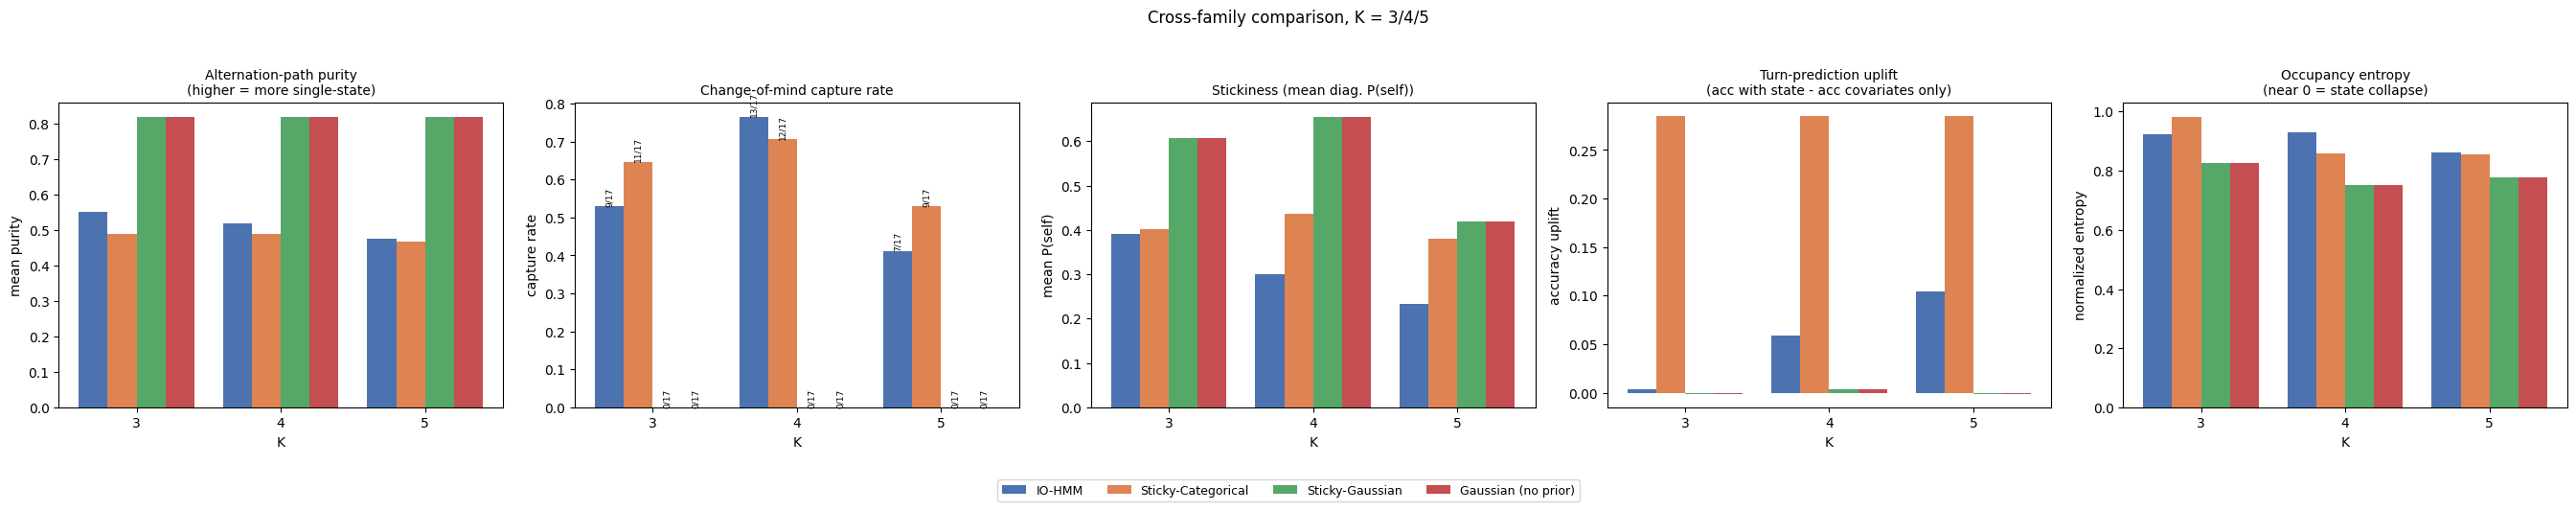

In [6]:
def grouped_bar(ax, df, metric, title, ylabel, annotate=None):
    families = [f for f in FAMILY_COLORS if f in df["family"].unique()]
    width = 0.8 / len(families)
    for i, fam in enumerate(families):
        sub = df[df.family == fam].sort_values("K")
        xs = np.arange(len(sub)) + i * width
        bars = ax.bar(xs, sub[metric], width=width, color=FAMILY_COLORS[fam], label=fam)
        if annotate is not None:
            for b, (_, row) in zip(bars, sub.iterrows()):
                ax.text(b.get_x() + b.get_width() / 2, b.get_height(), annotate(row),
                        ha="center", va="bottom", fontsize=6.5, rotation=90)
    n_fam = len(families)
    ax.set_xticks(np.arange(len(K_RANGE)) + width * (n_fam - 1) / 2)
    ax.set_xticklabels(K_RANGE)
    ax.set_xlabel("K"); ax.set_ylabel(ylabel); ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(1, 5, figsize=(27, 4.6))
grouped_bar(axes[0], comparison_df, "alternation_mean_purity",
            "Alternation-path purity\n(higher = more single-state)", "mean purity")
grouped_bar(axes[1], comparison_df, "com_capture_pct",
            "Change-of-mind capture rate", "capture rate",
            annotate=lambda row: f"{row.com_capture_k}/{row.com_n}")
grouped_bar(axes[2], comparison_df, "mean_diag_stickiness",
            "Stickiness (mean diag. P(self))", "mean P(self)")
grouped_bar(axes[3], comparison_df, "turn_acc_uplift",
            "Turn-prediction uplift\n(acc with state - acc covariates only)", "accuracy uplift")
grouped_bar(axes[4], comparison_df, "occupancy_entropy_norm",
            "Occupancy entropy\n(near 0 = state collapse)", "normalized entropy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels), bbox_to_anchor=(0.5, -0.1),
           fontsize=9)
fig.suptitle("Cross-family comparison, K = 3/4/5", y=1.03)
fig.tight_layout()
fig.savefig(OUT_DIR / "comparison_grouped_bars.png", dpi=140, bbox_inches="tight")
plt.show()

## 6. Qualitative deep-dive: top 2 (family, K) combinations

Ranked by a composite of purity + change-of-mind capture + stickiness (equal
weight), independently per (family, K) — not just per family — so the specific K
that works best for a given family is what gets inspected.

In [7]:
comparison_df["composite"] = comparison_df[
    ["alternation_mean_purity", "com_capture_pct", "mean_diag_stickiness"]
].mean(axis=1)
best_per_family = comparison_df.loc[comparison_df.groupby("family")["composite"].idxmax()]
top2 = best_per_family.sort_values("composite", ascending=False).head(2).reset_index(drop=True)
print("Top 2 (family, K) by composite score:")
display(top2[["family", "K", "composite", "alternation_mean_purity", "com_capture_pct",
              "mean_diag_stickiness"]])

Top 2 (family, K) by composite score:


,family,K,composite,alternation_mean_purity,com_capture_pct,mean_diag_stickiness
0,Sticky-Categorical,4,0.543439,0.488555,0.705882,0.435878
1,IO-HMM,4,0.527601,0.518583,0.764706,0.299513


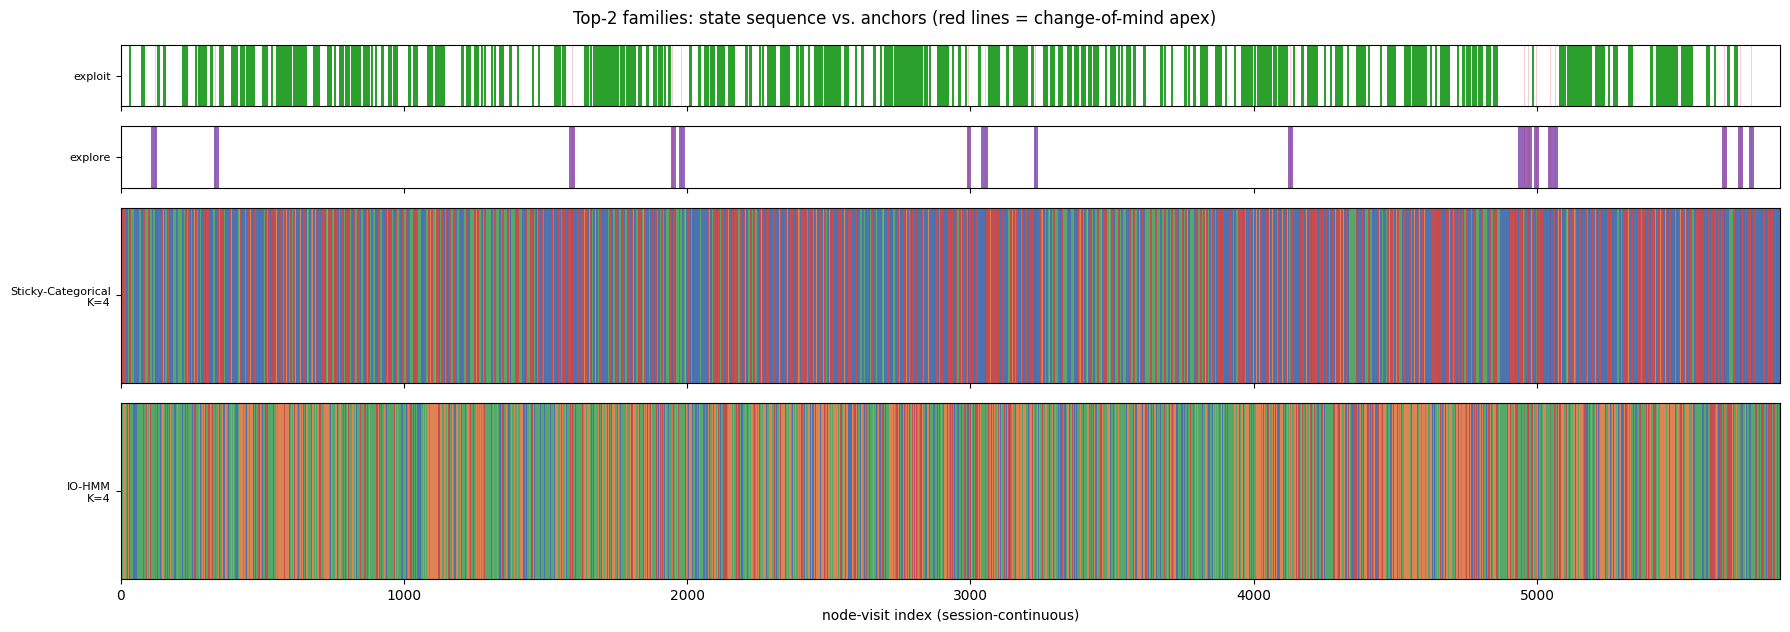

In [8]:
# State raster vs. behavioral anchors, for the top-2 (family, K)
n_visits = len(feat)
apex_x_all = feat.loc[feat["anchor_change_of_mind"], "node_visit_idx"].values

fig, axes = plt.subplots(
    2 + len(top2), 1, figsize=(18, 3 + 1.7 * len(top2)), sharex=True,
    gridspec_kw={"height_ratios": [0.35, 0.35] + [1] * len(top2)},
)
for ax, col, label, color in zip(
    axes[:2], ["anchor_exploit", "anchor_explore"], ["exploit", "explore"],
    ["#2ca02c", "#9467bd"],
):
    v = feat[col].values.astype(float)[None, :]
    ax.imshow(v, aspect="auto", cmap=ListedColormap(["white", color]), vmin=0, vmax=1,
              interpolation="nearest", extent=[0, n_visits, 0, 1])
    ax.set_yticks([0.5]); ax.set_yticklabels([label], fontsize=8); ax.set_ylim(0, 1)

for ax, (_, row) in zip(axes[2:], top2.iterrows()):
    fam, K = row["family"], int(row["K"])
    col = f"state_{FAMILY_SLUG[fam]}_K{K}"
    st = feat[col].values
    cmap = ListedColormap(palette[:K])
    ax.imshow(st[None, :], aspect="auto", cmap=cmap, vmin=-0.5, vmax=K - 0.5,
              interpolation="nearest", extent=[0, n_visits, 0, 1])
    ax.set_yticks([0.5]); ax.set_yticklabels([f"{fam}\nK={K}"], fontsize=8); ax.set_ylim(0, 1)

for ax in axes:
    for x in apex_x_all:
        ax.axvline(x, color="crimson", linewidth=0.5, alpha=0.3, zorder=1)

axes[-1].set_xlabel("node-visit index (session-continuous)")
fig.suptitle("Top-2 families: state sequence vs. anchors (red lines = change-of-mind apex)")
fig.tight_layout()
fig.savefig(OUT_DIR / "top2_raster_overview.png", dpi=140)
plt.show()

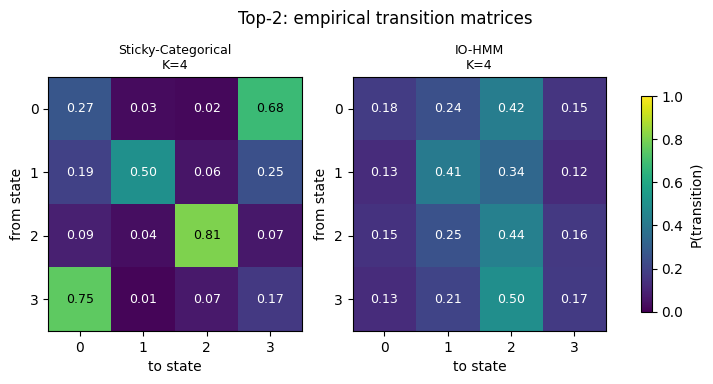

In [9]:
# Empirical transition matrices, top-2
fig, axes = plt.subplots(1, len(top2), figsize=(4.5 * len(top2), 4))
axes = np.atleast_1d(axes)
for ax, (_, row) in zip(axes, top2.iterrows()):
    fam, K = row["family"], int(row["K"])
    states = results[(fam, K)]["states"]
    tm = state_models.empirical_transition_matrix(states, K)
    im = ax.imshow(tm, cmap="viridis", vmin=0, vmax=1)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{tm[i, j]:.2f}", ha="center", va="center",
                    color="white" if tm[i, j] < 0.6 else "black", fontsize=9)
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xlabel("to state"); ax.set_ylabel("from state")
    ax.set_title(f"{fam}\nK={K}", fontsize=9)
fig.colorbar(im, ax=list(axes), shrink=0.7, label="P(transition)")
fig.suptitle("Top-2: empirical transition matrices")
fig.savefig(OUT_DIR / "top2_transition_matrices.png", dpi=140, bbox_inches="tight")
plt.show()

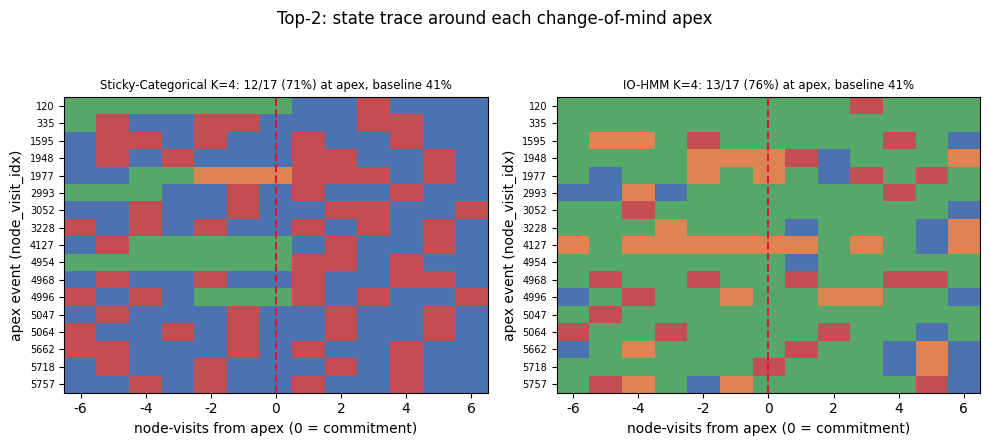

In [10]:
# Change-of-mind: state trace around each commitment apex, top-2
fig, axes = plt.subplots(1, len(top2), figsize=(5 * len(top2), 4.2))
axes = np.atleast_1d(axes)
for ax, (_, row) in zip(axes, top2.iterrows()):
    fam, K = row["family"], int(row["K"])
    col = f"state_{FAMILY_SLUG[fam]}_K{K}"
    mat, apex_idx = state_models.change_of_mind_window(feat, col, window=COM_WINDOW)
    cmap = ListedColormap(palette[:K])
    ax.imshow(np.ma.masked_invalid(mat), aspect="auto", cmap=cmap, vmin=-0.5, vmax=K - 0.5,
              interpolation="nearest")
    ax.axvline(COM_WINDOW, color="crimson", linewidth=1.5, linestyle="--")
    ax.set_yticks(range(len(apex_idx))); ax.set_yticklabels(apex_idx, fontsize=7)
    ax.set_xticks(range(0, 2 * COM_WINDOW + 1, 2))
    ax.set_xticklabels(range(-COM_WINDOW, COM_WINDOW + 1, 2))
    ax.set_xlabel("node-visits from apex (0 = commitment)")
    ax.set_ylabel("apex event (node_visit_idx)")
    ax.set_title(f"{fam} K={K}: {int(row.com_capture_k)}/{int(row.com_n)} "
                 f"({row.com_capture_pct:.0%}) at apex, baseline {row.com_baseline_occ:.0%}",
                 fontsize=8.5)
fig.suptitle("Top-2: state trace around each change-of-mind apex", y=1.05)
fig.tight_layout()
fig.savefig(OUT_DIR / "top2_change_of_mind.png", dpi=140, bbox_inches="tight")
plt.show()

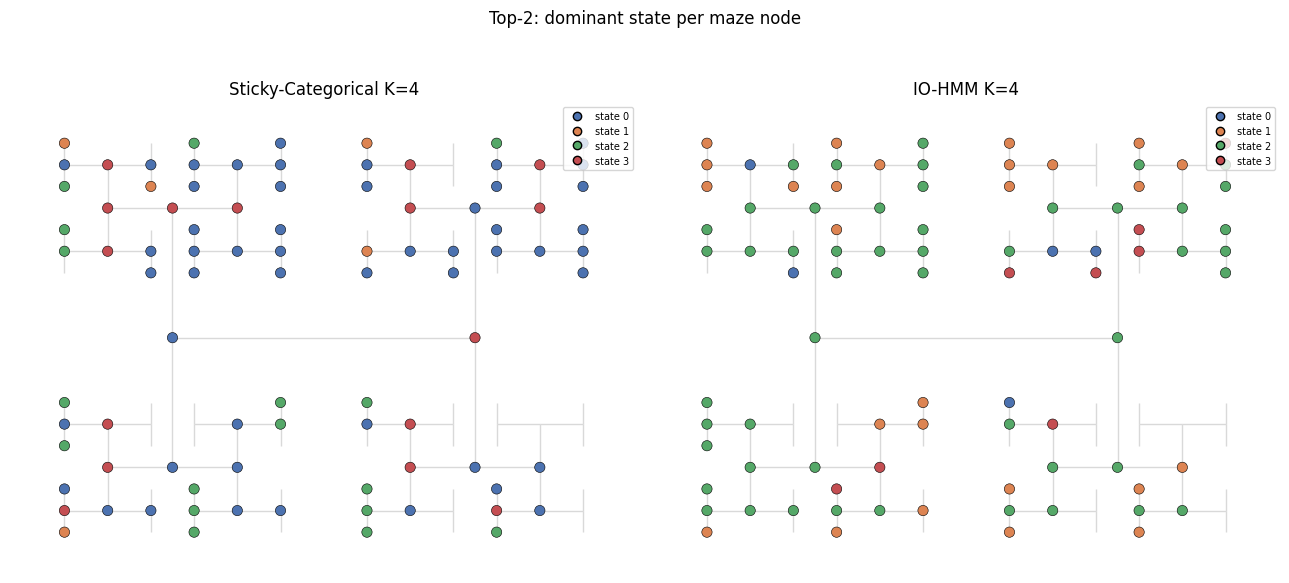

In [11]:
# Dominant state per maze node, top-2
pos = nx.get_node_attributes(G, "pos")
fig, axes = plt.subplots(1, len(top2), figsize=(6.5 * len(top2), 6.5))
axes = np.atleast_1d(axes)
for ax, (_, row) in zip(axes, top2.iterrows()):
    fam, K = row["family"], int(row["K"])
    col = f"state_{FAMILY_SLUG[fam]}_K{K}"
    node_state = feat.groupby("node_name")[col].agg(lambda s: s.value_counts().idxmax())
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="0.85")
    xs = [pos[n][0] for n in node_state.index]; ys = [pos[n][1] for n in node_state.index]
    cols = [palette[int(s)] for s in node_state.values]
    ax.scatter(xs, ys, c=cols, s=55, edgecolors="k", linewidths=0.4, zorder=3)
    ax.invert_yaxis(); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{fam} K={K}")
    handles = [plt.Line2D([0], [0], marker="o", ls="", mfc=palette[i], mec="k", label=f"state {i}")
               for i in range(K)]
    ax.legend(handles=handles, loc="upper right", fontsize=7)
fig.suptitle("Top-2: dominant state per maze node")
fig.tight_layout()
fig.savefig(OUT_DIR / "top2_maze.png", dpi=140)
plt.show()

## 7. Takeaways

- **Does stickiness help?** Compare `Sticky-Gaussian` vs `Gaussian (no prior)` in
  Section 5's plots (same features, only the prior differs) — the direct answer to
  the original hypothesis.
- **Does "based on turn directions alone" work?** `Sticky-Categorical`'s purity /
  change-of-mind columns vs the covariate-driven families.
- **Best overall**: see `top2` above and `comparison_summary.csv` for the full
  table.
- **`kappa=100` retune**: if Section 6's transition matrices show weak diagonal
  values relative to this session's ~5800 node-visits, revisit the constant in
  `state_models.STICKY_KAPPA`.

## 8. Save outputs

In [12]:
feat.to_csv(OUT_DIR / "node_states_all_families.csv", index=False)
comparison_df.to_csv(OUT_DIR / "comparison_summary.csv", index=False)

report = {}
for (family, K), r in results.items():
    key = f"{family}_K{K}"
    row = comparison_df[(comparison_df.family == family) & (comparison_df.K == K)].iloc[0]
    report[key] = {k: (v.item() if hasattr(v, "item") else v) for k, v in row.to_dict().items()}
with open(OUT_DIR / "validation_report.json", "w") as fh:
    json.dump(report, fh, indent=2, default=str)

print("wrote:", *[p.name for p in sorted(OUT_DIR.glob("*"))], sep="\n  ")

wrote:
  comparison_grouped_bars.png
  comparison_summary.csv
  node_states_all_families.csv
  top2_change_of_mind.png
  top2_maze.png
  top2_raster_overview.png
  top2_transition_matrices.png
  validation_report.json


## 9. Stickiness reality check: node run-length distribution, per state, per model

None of the metrics above directly answer "how many consecutive node-visits does
the model say the mouse stays in one state before switching?" `mean_diag_stickiness`
(self-transition probability) is only a proxy — under a simple geometric-duration
Markov chain, expected run length = `1/(1-p_self)`, e.g. `p_self=0.6` implies a mean
run of only **~2.5 node-visits**. We'd expect a real behavioral bout (a sustained
exploit or explore stretch) to last more like **15–20+ node-visits**. This section
computes the actual run-length distribution directly from each model's decoded state
sequence — no assumptions — for every state and every (family, K).

In [13]:
# Long-format table: one row per (family, K, state, individual run)
run_rows = []
for (family, K), r in results.items():
    rl = state_models.state_run_lengths(r["states"])
    for state, lengths in rl.items():
        for length in lengths:
            run_rows.append({"family": family, "K": K, "state": state, "run_length": length})
run_df = pd.DataFrame(run_rows)
run_df.to_csv(OUT_DIR / "run_length_distribution.csv", index=False)

run_summary = (run_df.groupby(["family", "K", "state"])["run_length"]
               .agg(["mean", "median", "std", "min", "max", "count"])
               .reset_index())
run_summary.to_csv(OUT_DIR / "run_length_summary.csv", index=False)

EXPECTED_LO, EXPECTED_HI = 15, 20
frac_below = (run_summary["mean"] < EXPECTED_LO).mean()
print(f"{frac_below:.0%} of (family, K, state) combinations have mean run length "
      f"< {EXPECTED_LO} node-visits")
print(f"\nOverall mean run length across ALL (family, K, state): "
      f"{run_summary['mean'].mean():.1f} node-visits")
print(f"Overall median run length across ALL (family, K, state): "
      f"{run_summary['median'].median():.1f} node-visits")

print("\n--- lowest mean run lengths ---")
display(run_summary.sort_values("mean").head(8))
print("--- highest mean run lengths ---")
display(run_summary.sort_values("mean", ascending=False).head(8))

100% of (family, K, state) combinations have mean run length < 15 node-visits

Overall mean run length across ALL (family, K, state): 3.4 node-visits
Overall median run length across ALL (family, K, state): 1.0 node-visits

--- lowest mean run lengths ---


,family,K,state,mean,median,std,min,max,count
8,Gaussian (no prior),5,1,1.000000,1.0,0.000000,1,1,401
44,Sticky-Gaussian,5,1,1.000000,1.0,0.000000,1,1,401
47,Sticky-Gaussian,5,4,1.027375,1.0,0.229075,1,3,621
11,Gaussian (no prior),5,4,1.027375,1.0,0.229075,1,3,621
21,IO-HMM,5,2,1.041543,1.0,0.214215,1,3,337
20,IO-HMM,5,1,1.138829,1.0,0.370414,1,3,461
1,Gaussian (no prior),3,1,1.162047,1.0,0.393882,1,3,938
37,Sticky-Gaussian,3,1,1.162047,1.0,0.393882,1,3,938


--- highest mean run lengths ---


,family,K,state,mean,median,std,min,max,count
0,Gaussian (no prior),3,0,10.905263,9.0,3.750386,9,30,95
10,Gaussian (no prior),5,3,10.905263,9.0,3.750386,9,30,95
36,Sticky-Gaussian,3,0,10.905263,9.0,3.750386,9,30,95
46,Sticky-Gaussian,5,3,10.905263,9.0,3.750386,9,30,95
3,Gaussian (no prior),4,0,9.000000,9.0,0.000000,9,9,64
39,Sticky-Gaussian,4,0,9.000000,9.0,0.000000,9,9,64
45,Sticky-Gaussian,5,2,7.519187,7.0,1.923060,1,27,443
9,Gaussian (no prior),5,2,7.519187,7.0,1.923060,1,27,443


,family,K,overall_mean,overall_median,n_runs,mean_of_per_state_means
0,Gaussian (no prior),3,3.120938,1.0,1877,5.496370
1,Gaussian (no prior),4,3.164776,1.0,1851,5.006921
2,Gaussian (no prior),5,3.119276,1.0,1878,4.374642
3,IO-HMM,3,1.870968,1.0,3131,1.821334
4,IO-HMM,4,1.543203,1.0,3796,1.474852
5,IO-HMM,5,1.482663,1.0,3951,1.351235
6,Sticky-Categorical,3,1.546054,1.0,3789,2.391774
7,Sticky-Categorical,4,1.516831,1.0,3862,2.441034
8,Sticky-Categorical,5,1.384216,1.0,4232,1.816787
9,Sticky-Gaussian,3,3.120938,1.0,1877,5.496370


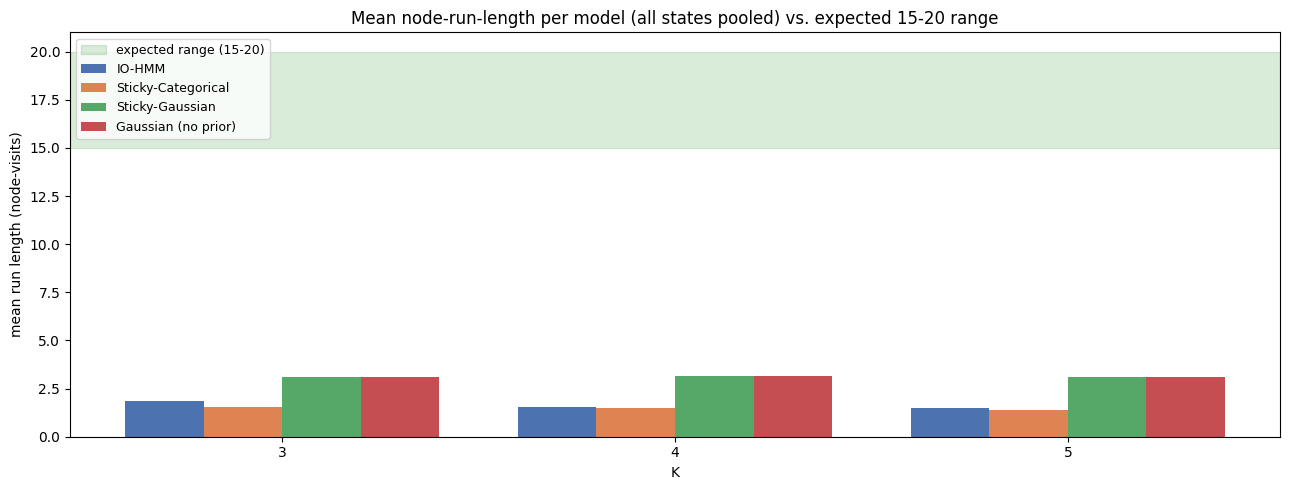

In [14]:
# Mean run length per model (pooled across states and per-state-average), vs the
# 15-20 expected range
model_summary = (run_df.groupby(["family", "K"])["run_length"]
                  .agg(overall_mean="mean", overall_median="median", n_runs="count")
                  .reset_index())
state_mean_of_means = (run_summary.groupby(["family", "K"])["mean"].mean()
                        .rename("mean_of_per_state_means").reset_index())
model_summary = model_summary.merge(state_mean_of_means, on=["family", "K"])
model_summary.to_csv(OUT_DIR / "run_length_model_summary.csv", index=False)
display(model_summary)

fig, ax = plt.subplots(figsize=(13, 5))
families = [f for f in FAMILY_COLORS if f in model_summary["family"].unique()]
width = 0.8 / len(families)
for i, fam in enumerate(families):
    sub = model_summary[model_summary.family == fam].sort_values("K")
    xs = np.arange(len(sub)) + i * width
    ax.bar(xs, sub["overall_mean"], width=width, color=FAMILY_COLORS[fam], label=fam)
ax.axhspan(EXPECTED_LO, EXPECTED_HI, color="green", alpha=0.15,
           label=f"expected range ({EXPECTED_LO}-{EXPECTED_HI})")
ax.set_xticks(np.arange(len(K_RANGE)) + width * (len(families) - 1) / 2)
ax.set_xticklabels(K_RANGE)
ax.set_xlabel("K"); ax.set_ylabel("mean run length (node-visits)")
ax.set_title("Mean node-run-length per model (all states pooled) vs. expected 15-20 range")
ax.legend(fontsize=9, loc="upper left")
fig.tight_layout()
fig.savefig(OUT_DIR / "run_length_mean_vs_expected.png", dpi=140)
plt.show()

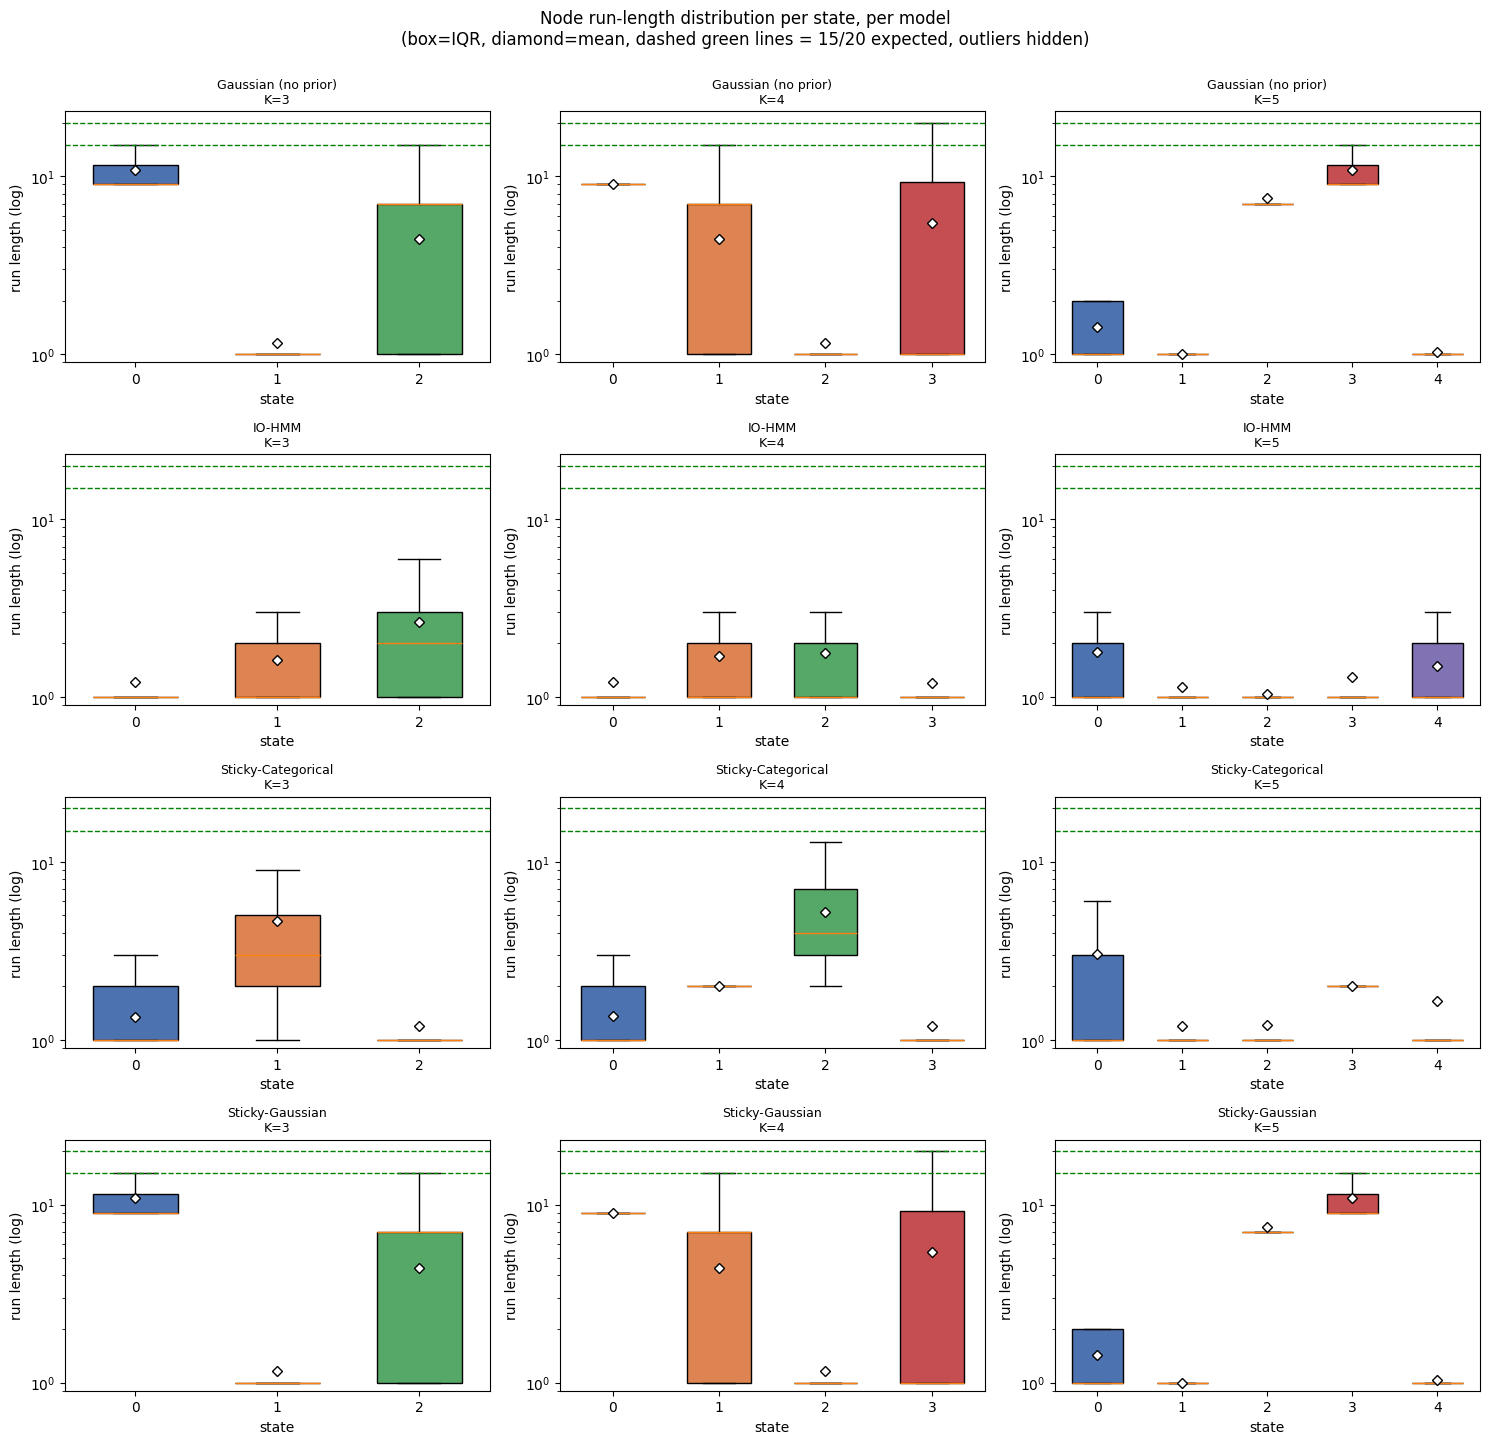

In [15]:
# Full distribution, per state, per model (log-scale y since run lengths are heavily
# right-skewed: many short 1-3 node runs, a few long ones)
combos = sorted(results.keys(), key=lambda t: (t[0], t[1]))
ncols = 3
nrows = int(np.ceil(len(combos) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), squeeze=False)
for ax, (fam, K) in zip(axes.flat, combos):
    sub = run_df[(run_df.family == fam) & (run_df.K == K)]
    states_present = sorted(sub.state.unique())
    data = [sub[sub.state == s]["run_length"].values for s in states_present]
    bp = ax.boxplot(data, positions=range(len(states_present)), widths=0.6,
                     showfliers=False, patch_artist=True, showmeans=True,
                     meanprops=dict(marker="D", markerfacecolor="white",
                                    markeredgecolor="black", markersize=5))
    for patch, s in zip(bp["boxes"], states_present):
        patch.set_facecolor(palette[s])
    ax.axhline(EXPECTED_LO, color="green", linestyle="--", linewidth=1)
    ax.axhline(EXPECTED_HI, color="green", linestyle="--", linewidth=1)
    ax.set_yscale("log"); ax.set_ylim(bottom=0.9)
    ax.set_xticks(range(len(states_present))); ax.set_xticklabels(states_present)
    ax.set_xlabel("state"); ax.set_ylabel("run length (log)")
    ax.set_title(f"{fam}\nK={K}", fontsize=9)
for ax in axes.flat[len(combos):]:
    ax.axis("off")
fig.suptitle("Node run-length distribution per state, per model\n"
             "(box=IQR, diamond=mean, dashed green lines = 15/20 expected, outliers hidden)",
             y=1.0)
fig.tight_layout()
fig.savefig(OUT_DIR / "run_length_boxplots_grid.png", dpi=140, bbox_inches="tight")
plt.show()